In [2]:
import json

candidates = []

with open("F:\\autorecruit-\\data_forensic _files\\candidates.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        candidates.append(json.loads(line))

In [3]:
import pandas as pd
skills_rows = []

for c in candidates:

    cid = c["candidate_id"]

    for skill in c["skills"]:

        skills_rows.append({
            "candidate_id": cid,
            "skill": skill["name"],
            "proficiency": skill["proficiency"],
            "duration_months": skill["duration_months"],
            "endorsements": skill["endorsements"]
        })

skills_df = pd.DataFrame(skills_rows)

print(skills_df.shape)
skills_df.head()

(960302, 5)


,candidate_id,skill,proficiency,duration_months,endorsements
0,CAND_0000001,Tailwind,intermediate,13,3
1,CAND_0000001,NLP,advanced,26,37
2,CAND_0000001,Image Classification,advanced,40,7
3,CAND_0000001,Fine-tuning LLMs,advanced,36,21
4,CAND_0000001,Weights & Biases,intermediate,30,13


In [4]:
candidate_corpus = {}

for c in candidates:

    cid = c["candidate_id"]

    summary = c["profile"]["summary"]

    headline = c["profile"]["headline"]

    descriptions = " ".join([
        job["description"]
        for job in c["career_history"]
    ])

    candidate_corpus[cid] = " ".join([
        headline,
        summary,
        descriptions
    ])

In [5]:
candidate_corpus

{'CAND_0000001': "Backend Engineer | SQL, Spark, Cloud Software / data professional with 6.9 years of experience building data pipelines, backend systems, and analytics infrastructure. I'm a backend/data hybrid — Spark, Airflow, SQL warehouses are home territory; I'm building competence on the ML side. My toolkit is solid on the data engineering side — Python, SQL, Spark, Airflow, warehouse design — and I've completed a couple of self-directed ML projects (Kaggle competitions, side projects fine-tuning small models). Interested in transitioning toward more AI/ML-focused work, ideally at a company where I can leverage my existing data-infra skills while learning modern ML practice. Implemented streaming data pipelines on Kafka and Spark Streaming for a real-time user-activity processing platform. Designed the schema-registry integration, the watermark/state management approach, and the deduplication logic for late-arriving events. Worked closely with the data science team to make sure f

In [6]:
evidence_rows = []

for c in candidates:

    cid = c["candidate_id"]

    corpus = candidate_corpus[cid].lower()

    total_skills = 0
    supported_skills = 0

    for skill in c["skills"]:

        total_skills += 1

        if skill["name"].lower() in corpus:
            supported_skills += 1

    evidence_rows.append({
        "candidate_id": cid,
        "skills_claimed": total_skills,
        "skills_supported": supported_skills
    })

evidence_df = pd.DataFrame(evidence_rows)
print(evidence_df.shape)
evidence_df.head()

(100000, 3)


,candidate_id,skills_claimed,skills_supported
0,CAND_0000001,17,0
1,CAND_0000002,9,1
2,CAND_0000003,6,1
3,CAND_0000004,10,1
4,CAND_0000005,6,0


In [7]:
evidence_df["evidence_ratio"] = (
    evidence_df["skills_supported"]
    /
    evidence_df["skills_claimed"]
)

evidence_df[["candidate_id", "skills_claimed", "skills_supported", "evidence_ratio"]].head()

,candidate_id,skills_claimed,skills_supported,evidence_ratio
0,CAND_0000001,17,0,0.000000
1,CAND_0000002,9,1,0.111111
2,CAND_0000003,6,1,0.166667
3,CAND_0000004,10,1,0.100000
4,CAND_0000005,6,0,0.000000


In [8]:
evidence_df.sort_values(
    "evidence_ratio"
)

,candidate_id,skills_claimed,skills_supported,evidence_ratio
46,CAND_0000047,7,0,0.000000
54512,CAND_0054513,7,0,0.000000
54511,CAND_0054512,5,0,0.000000
54509,CAND_0054510,8,0,0.000000
54507,CAND_0054508,11,0,0.000000
...,...,...,...,...
46378,CAND_0046379,8,5,0.625000
5126,CAND_0005127,6,4,0.666667
49829,CAND_0049830,6,4,0.666667
44891,CAND_0044892,6,4,0.666667


In [9]:
inflation_rows = []

for c in candidates:

    cid = c["candidate_id"]

    corpus = candidate_corpus[cid].lower()

    inflated = 0

    for skill in c["skills"]:

        prof = skill["proficiency"]

        found = (
            skill["name"].lower()
            in corpus
        )

        if prof == "advanced" and not found:
            inflated += 1

    inflation_rows.append({
        "candidate_id": cid,
        "inflated_skills": inflated
    })

inflation_df = pd.DataFrame(
    inflation_rows
)

In [10]:
inflation_df

,candidate_id,inflated_skills
0,CAND_0000001,7
1,CAND_0000002,0
2,CAND_0000003,0
3,CAND_0000004,0
4,CAND_0000005,1
...,...,...
99995,CAND_0099996,0
99996,CAND_0099997,0
99997,CAND_0099998,1
99998,CAND_0099999,1


In [11]:
jd_keywords = [

    "retrieval",

    "ranking",

    "embedding",

    "vector",

    "python",

    "evaluation",

    "ndcg",

    "mrr",

    "map",

    "search",

    "recommendation"
]

In [12]:
jd_rows = []

for cid, corpus in candidate_corpus.items():

    text = corpus.lower()

    hits = 0

    for kw in jd_keywords:

        if kw in text:
            hits += 1

    jd_rows.append({
        "candidate_id": cid,
        "jd_evidence_hits": hits
    })

jd_df = pd.DataFrame(jd_rows)

jd_df

,candidate_id,jd_evidence_hits
0,CAND_0000001,1
1,CAND_0000002,1
2,CAND_0000003,0
3,CAND_0000004,1
4,CAND_0000005,0
...,...,...
99995,CAND_0099996,1
99996,CAND_0099997,1
99997,CAND_0099998,1
99998,CAND_0099999,1


In [13]:
merged = (
    evidence_df
    .merge(
        inflation_df,
        on="candidate_id"
    )
)

In [14]:
merged

,candidate_id,skills_claimed,skills_supported,evidence_ratio,inflated_skills
0,CAND_0000001,17,0,0.000000,7
1,CAND_0000002,9,1,0.111111,0
2,CAND_0000003,6,1,0.166667,0
3,CAND_0000004,10,1,0.100000,0
4,CAND_0000005,6,0,0.000000,1
...,...,...,...,...,...
99995,CAND_0099996,10,1,0.100000,0
99996,CAND_0099997,7,1,0.142857,0
99997,CAND_0099998,10,0,0.000000,1
99998,CAND_0099999,7,0,0.000000,1


In [15]:
merged[
    "skill_credibility_score"
] = (

    merged["evidence_ratio"]

    -

    (
        merged["inflated_skills"]
        /
        merged["skills_claimed"]
    )
)

In [16]:
merged_df = merged[merged["skill_credibility_score"] > 0]

merged_df

,candidate_id,skills_claimed,skills_supported,evidence_ratio,inflated_skills,skill_credibility_score
1,CAND_0000002,9,1,0.111111,0,0.111111
2,CAND_0000003,6,1,0.166667,0,0.166667
3,CAND_0000004,10,1,0.100000,0,0.100000
8,CAND_0000009,6,1,0.166667,0,0.166667
16,CAND_0000017,8,1,0.125000,0,0.125000
...,...,...,...,...,...,...
99975,CAND_0099976,7,1,0.142857,0,0.142857
99984,CAND_0099985,7,1,0.142857,0,0.142857
99993,CAND_0099994,16,1,0.062500,0,0.062500
99995,CAND_0099996,10,1,0.100000,0,0.100000


In [17]:
merged_df.sort_values(
    "skill_credibility_score",
    ascending=False
)

,candidate_id,skills_claimed,skills_supported,evidence_ratio,inflated_skills,skill_credibility_score
5126,CAND_0005127,6,4,0.666667,0,0.666667
49829,CAND_0049830,6,4,0.666667,0,0.666667
15744,CAND_0015745,6,4,0.666667,0,0.666667
44891,CAND_0044892,6,4,0.666667,0,0.666667
4725,CAND_0004726,10,6,0.600000,0,0.600000
...,...,...,...,...,...,...
46433,CAND_0046434,21,3,0.142857,2,0.047619
79037,CAND_0079038,22,4,0.181818,3,0.045455
49886,CAND_0049887,22,3,0.136364,2,0.045455
71244,CAND_0071245,22,3,0.136364,2,0.045455


In [18]:
intent_rows = []

for c in candidates:

    s = c["redrob_signals"]

    intent_rows.append({

        "candidate_id":
        c["candidate_id"],

        "open_to_work":
        s["open_to_work_flag"],

        "applications":
        s["applications_submitted_30d"],

        "response_rate":
        s["recruiter_response_rate"],

        "notice_period":
        s["notice_period_days"]
    })

In [19]:
intent_rows

[{'candidate_id': 'CAND_0000001',
  'open_to_work': True,
  'applications': 2,
  'response_rate': 0.34,
  'notice_period': 60},
 {'candidate_id': 'CAND_0000002',
  'open_to_work': True,
  'applications': 1,
  'response_rate': 0.29,
  'notice_period': 60},
 {'candidate_id': 'CAND_0000003',
  'open_to_work': False,
  'applications': 9,
  'response_rate': 0.46,
  'notice_period': 150},
 {'candidate_id': 'CAND_0000004',
  'open_to_work': False,
  'applications': 9,
  'response_rate': 0.26,
  'notice_period': 120},
 {'candidate_id': 'CAND_0000005',
  'open_to_work': True,
  'applications': 2,
  'response_rate': 0.37,
  'notice_period': 30},
 {'candidate_id': 'CAND_0000006',
  'open_to_work': False,
  'applications': 8,
  'response_rate': 0.12,
  'notice_period': 150},
 {'candidate_id': 'CAND_0000007',
  'open_to_work': False,
  'applications': 1,
  'response_rate': 0.62,
  'notice_period': 30},
 {'candidate_id': 'CAND_0000008',
  'open_to_work': False,
  'applications': 5,
  'response_rate'

In [20]:
def intent_score(row):

    score = 0

    if row["open_to_work"]:
        score += 40

    score += (
        min(
            row["applications"],
            10
        ) * 3
    )

    score += (
        row["response_rate"]
        * 30
    )

    return score

intent_scores = []

print(intent_rows[4])
# intent_df = pd.DataFrame(intent_rows)
# intent_df

{'candidate_id': 'CAND_0000005', 'open_to_work': True, 'applications': 2, 'response_rate': 0.37, 'notice_period': 30}


In [21]:
signal_rows = []

for c in candidates:

    s = c["redrob_signals"]

    signal_rows.append({

        "candidate_id": c["candidate_id"],

        "profile_completeness":
            s["profile_completeness_score"],

        "open_to_work":
            s["open_to_work_flag"],

        "response_rate":
            s["recruiter_response_rate"],

        "response_time":
            s["avg_response_time_hours"],

        "views":
            s["profile_views_received_30d"],

        "applications":
            s["applications_submitted_30d"],

        "connections":
            s["connection_count"],

        "search_appearance":
            s["search_appearance_30d"],

        "saved":
            s["saved_by_recruiters_30d"],

        "notice_period":
            s["notice_period_days"],

        "completion_rate":
            s["interview_completion_rate"],

        "offer_acceptance":
            s["offer_acceptance_rate"]
    })

signals_df = pd.DataFrame(signal_rows)

In [22]:
signals_df

,candidate_id,profile_completeness,open_to_work,response_rate,response_time,views,applications,connections,search_appearance,saved,notice_period,completion_rate,offer_acceptance
0,CAND_0000001,86.9,True,0.34,177.8,23,2,356,249,4,60,0.71,0.58
1,CAND_0000002,78.7,True,0.29,171.6,7,1,179,107,10,60,0.62,-1.00
2,CAND_0000003,31.9,False,0.46,119.4,1,9,19,28,4,150,0.86,-1.00
3,CAND_0000004,28.5,False,0.26,104.1,3,9,485,5,8,120,0.35,-1.00
4,CAND_0000005,84.6,True,0.37,116.7,12,2,300,67,1,30,0.74,-1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CAND_0099996,41.4,False,0.45,259.8,52,5,325,98,7,30,0.87,-1.00
99996,CAND_0099997,42.7,True,0.41,108.6,42,4,292,49,0,30,0.38,-1.00
99997,CAND_0099998,75.9,False,0.33,139.0,84,0,442,187,26,90,0.79,0.74
99998,CAND_0099999,49.1,True,0.46,13.7,81,0,345,102,3,120,0.49,0.65


In [23]:
signals_df.describe()

,profile_completeness,response_rate,response_time,views,applications,connections,search_appearance,saved,notice_period,completion_rate,offer_acceptance
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,56.758180,0.436574,132.702744,47.98525,5.390360,345.664890,117.543800,7.658700,87.385800,0.619510,-0.403604
std,17.274069,0.214122,75.238241,32.05187,3.494796,208.145694,92.825891,5.921436,36.589628,0.170662,0.732439
min,25.000000,0.020000,2.100000,0.00000,0.000000,10.000000,0.000000,0.000000,0.000000,0.300000,-1.000000
25%,42.200000,0.250000,68.300000,23.00000,2.000000,174.000000,52.000000,3.000000,60.000000,0.480000,-1.000000
50%,56.800000,0.440000,129.900000,45.00000,5.000000,335.000000,105.000000,7.000000,90.000000,0.620000,-1.000000
75%,71.600000,0.620000,193.300000,68.00000,8.000000,497.000000,158.000000,11.000000,120.000000,0.760000,0.400000
max,99.900000,0.950000,280.000000,374.00000,24.000000,1898.000000,1490.000000,80.000000,150.000000,1.000000,0.930000


In [24]:
(signals_df == -1).sum()

candidate_id                0
profile_completeness        0
open_to_work                0
response_rate               0
response_time               0
views                       0
applications                0
connections                 0
search_appearance           0
saved                       0
notice_period               0
completion_rate             0
offer_acceptance        59554
dtype: int64

array([[<Axes: title={'center': 'profile_completeness'}>,
        <Axes: title={'center': 'response_rate'}>,
        <Axes: title={'center': 'response_time'}>],
       [<Axes: title={'center': 'views'}>,
        <Axes: title={'center': 'applications'}>,
        <Axes: title={'center': 'connections'}>],
       [<Axes: title={'center': 'search_appearance'}>,
        <Axes: title={'center': 'saved'}>,
        <Axes: title={'center': 'notice_period'}>],
       [<Axes: title={'center': 'completion_rate'}>,
        <Axes: title={'center': 'offer_acceptance'}>, <Axes: >]],
      dtype=object)

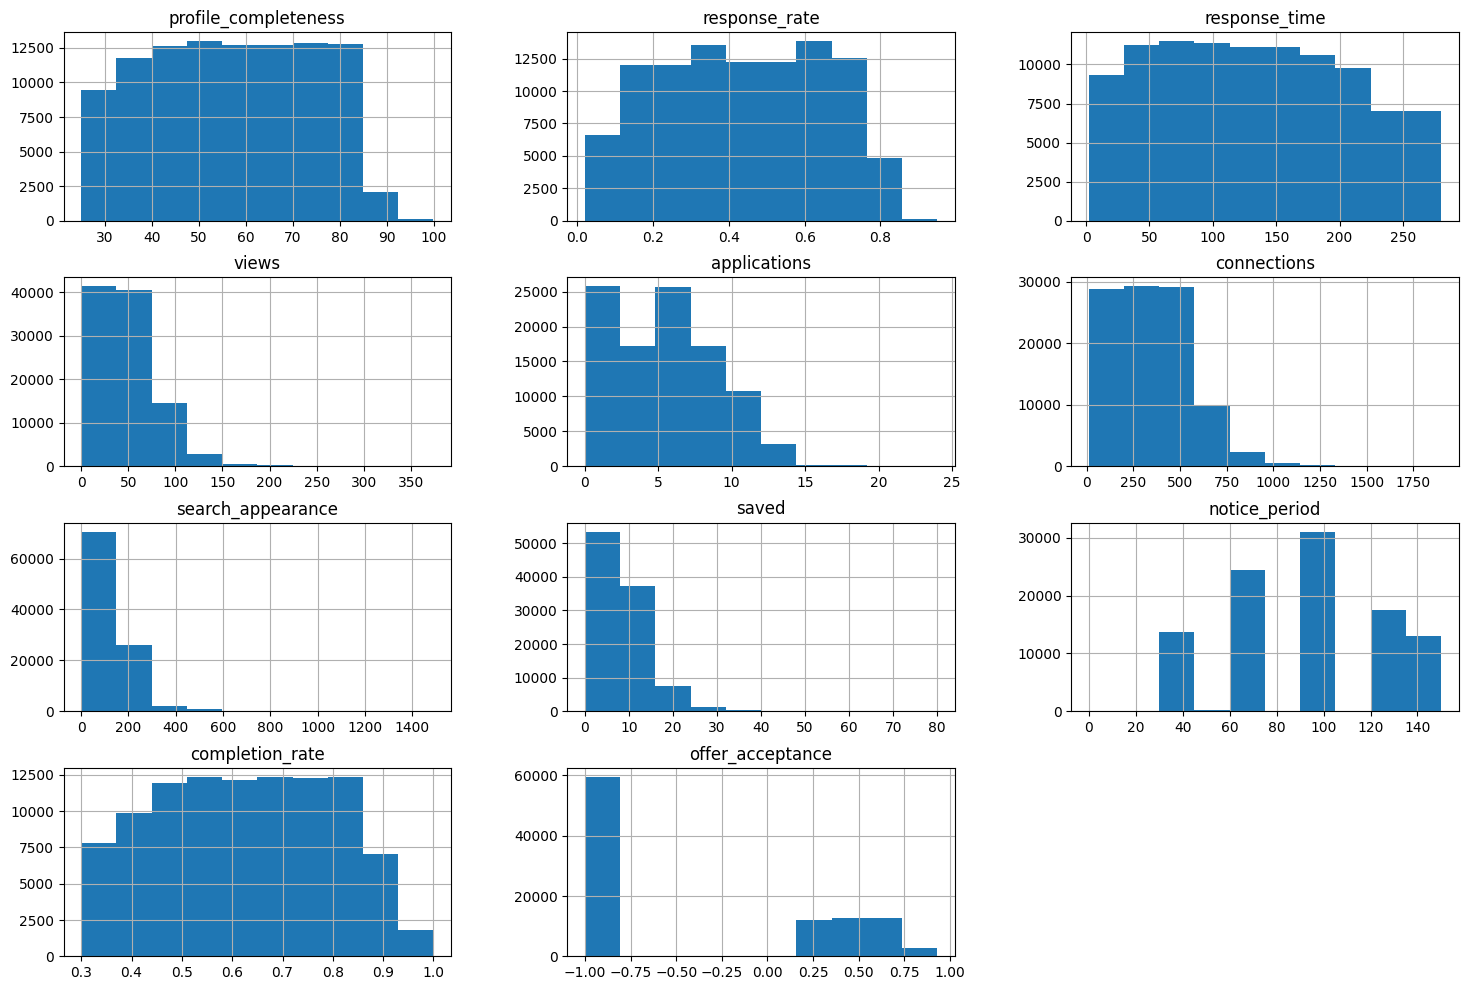

In [25]:
signals_df.hist(
    figsize=(18,12)
)

In [26]:
import pandas as pd
import numpy as np

availability_df = signals_df.copy()

In [27]:
availability_score = signals_df[["open_to_work","notice_period"]]

availability_score

,open_to_work,notice_period
0,True,60
1,True,60
2,False,150
3,False,120
4,True,30
...,...,...
99995,False,30
99996,True,30
99997,False,90
99998,True,120


In [28]:
availability_df["notice_score"] = (
    1 -
    (
        availability_df["notice_period"]
        /
        availability_df["notice_period"].max()
    )
)

availability_df

,candidate_id,profile_completeness,open_to_work,response_rate,response_time,views,applications,connections,search_appearance,saved,notice_period,completion_rate,offer_acceptance,notice_score
0,CAND_0000001,86.9,True,0.34,177.8,23,2,356,249,4,60,0.71,0.58,0.6
1,CAND_0000002,78.7,True,0.29,171.6,7,1,179,107,10,60,0.62,-1.00,0.6
2,CAND_0000003,31.9,False,0.46,119.4,1,9,19,28,4,150,0.86,-1.00,0.0
3,CAND_0000004,28.5,False,0.26,104.1,3,9,485,5,8,120,0.35,-1.00,0.2
4,CAND_0000005,84.6,True,0.37,116.7,12,2,300,67,1,30,0.74,-1.00,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CAND_0099996,41.4,False,0.45,259.8,52,5,325,98,7,30,0.87,-1.00,0.8
99996,CAND_0099997,42.7,True,0.41,108.6,42,4,292,49,0,30,0.38,-1.00,0.8
99997,CAND_0099998,75.9,False,0.33,139.0,84,0,442,187,26,90,0.79,0.74,0.4
99998,CAND_0099999,49.1,True,0.46,13.7,81,0,345,102,3,120,0.49,0.65,0.2


In [29]:
availability_df["availability_score"] = (

    0.6 *
    availability_df["open_to_work"]

    +

    0.4 *
    availability_df["notice_score"]

)

availability_df

,candidate_id,profile_completeness,open_to_work,response_rate,response_time,views,applications,connections,search_appearance,saved,notice_period,completion_rate,offer_acceptance,notice_score,availability_score
0,CAND_0000001,86.9,True,0.34,177.8,23,2,356,249,4,60,0.71,0.58,0.6,0.84
1,CAND_0000002,78.7,True,0.29,171.6,7,1,179,107,10,60,0.62,-1.00,0.6,0.84
2,CAND_0000003,31.9,False,0.46,119.4,1,9,19,28,4,150,0.86,-1.00,0.0,0.00
3,CAND_0000004,28.5,False,0.26,104.1,3,9,485,5,8,120,0.35,-1.00,0.2,0.08
4,CAND_0000005,84.6,True,0.37,116.7,12,2,300,67,1,30,0.74,-1.00,0.8,0.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CAND_0099996,41.4,False,0.45,259.8,52,5,325,98,7,30,0.87,-1.00,0.8,0.32
99996,CAND_0099997,42.7,True,0.41,108.6,42,4,292,49,0,30,0.38,-1.00,0.8,0.92
99997,CAND_0099998,75.9,False,0.33,139.0,84,0,442,187,26,90,0.79,0.74,0.4,0.16
99998,CAND_0099999,49.1,True,0.46,13.7,81,0,345,102,3,120,0.49,0.65,0.2,0.68


Component 2: Responsiveness Score


In [30]:
availability_df["response_time_score"] = (

    1 -

    (
        availability_df["response_time"]
        /
        availability_df["response_time"].max()
    )

)

availability_df["response_time_score"]

0        0.365000
1        0.387143
2        0.573571
3        0.628214
4        0.583214
           ...   
99995    0.072143
99996    0.612143
99997    0.503571
99998    0.951071
99999    0.028571
Name: response_time_score, Length: 100000, dtype: float64

In [31]:
availability_df["responsiveness_score"] = (

    0.7 *
    availability_df["response_rate"]

    +

    0.3 *
    availability_df["response_time_score"]

)

availability_df["responsiveness_score"]

0        0.347500
1        0.319143
2        0.494071
3        0.370464
4        0.433964
           ...   
99995    0.336643
99996    0.470643
99997    0.382071
99998    0.607321
99999    0.134571
Name: responsiveness_score, Length: 100000, dtype: float64

Component 3: Recruiter Demand Score

In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

availability_df[
[
"views_norm",
"search_norm",
"saved_norm"
]
] = scaler.fit_transform(

availability_df[
[
"views",
"search_appearance",
"saved"
]
]

)

In [33]:
availability_df

,candidate_id,profile_completeness,open_to_work,response_rate,response_time,views,applications,connections,search_appearance,saved,notice_period,completion_rate,offer_acceptance,notice_score,availability_score,response_time_score,responsiveness_score,views_norm,search_norm,saved_norm
0,CAND_0000001,86.9,True,0.34,177.8,23,2,356,249,4,60,0.71,0.58,0.6,0.84,0.365000,0.347500,0.061497,0.167114,0.0500
1,CAND_0000002,78.7,True,0.29,171.6,7,1,179,107,10,60,0.62,-1.00,0.6,0.84,0.387143,0.319143,0.018717,0.071812,0.1250
2,CAND_0000003,31.9,False,0.46,119.4,1,9,19,28,4,150,0.86,-1.00,0.0,0.00,0.573571,0.494071,0.002674,0.018792,0.0500
3,CAND_0000004,28.5,False,0.26,104.1,3,9,485,5,8,120,0.35,-1.00,0.2,0.08,0.628214,0.370464,0.008021,0.003356,0.1000
4,CAND_0000005,84.6,True,0.37,116.7,12,2,300,67,1,30,0.74,-1.00,0.8,0.92,0.583214,0.433964,0.032086,0.044966,0.0125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CAND_0099996,41.4,False,0.45,259.8,52,5,325,98,7,30,0.87,-1.00,0.8,0.32,0.072143,0.336643,0.139037,0.065772,0.0875
99996,CAND_0099997,42.7,True,0.41,108.6,42,4,292,49,0,30,0.38,-1.00,0.8,0.92,0.612143,0.470643,0.112299,0.032886,0.0000
99997,CAND_0099998,75.9,False,0.33,139.0,84,0,442,187,26,90,0.79,0.74,0.4,0.16,0.503571,0.382071,0.224599,0.125503,0.3250
99998,CAND_0099999,49.1,True,0.46,13.7,81,0,345,102,3,120,0.49,0.65,0.2,0.68,0.951071,0.607321,0.216578,0.068456,0.0375


In [34]:
availability_df["demand_score"] = (

    0.5 *
    availability_df["saved_norm"]

    +

    0.3 *
    availability_df["views_norm"]

    +

    0.2 *
    availability_df["search_norm"]

)

availability_df

,candidate_id,profile_completeness,open_to_work,response_rate,response_time,views,applications,connections,search_appearance,saved,...,completion_rate,offer_acceptance,notice_score,availability_score,response_time_score,responsiveness_score,views_norm,search_norm,saved_norm,demand_score
0,CAND_0000001,86.9,True,0.34,177.8,23,2,356,249,4,...,0.71,0.58,0.6,0.84,0.365000,0.347500,0.061497,0.167114,0.0500,0.076872
1,CAND_0000002,78.7,True,0.29,171.6,7,1,179,107,10,...,0.62,-1.00,0.6,0.84,0.387143,0.319143,0.018717,0.071812,0.1250,0.082477
2,CAND_0000003,31.9,False,0.46,119.4,1,9,19,28,4,...,0.86,-1.00,0.0,0.00,0.573571,0.494071,0.002674,0.018792,0.0500,0.029561
3,CAND_0000004,28.5,False,0.26,104.1,3,9,485,5,8,...,0.35,-1.00,0.2,0.08,0.628214,0.370464,0.008021,0.003356,0.1000,0.053078
4,CAND_0000005,84.6,True,0.37,116.7,12,2,300,67,1,...,0.74,-1.00,0.8,0.92,0.583214,0.433964,0.032086,0.044966,0.0125,0.024869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CAND_0099996,41.4,False,0.45,259.8,52,5,325,98,7,...,0.87,-1.00,0.8,0.32,0.072143,0.336643,0.139037,0.065772,0.0875,0.098616
99996,CAND_0099997,42.7,True,0.41,108.6,42,4,292,49,0,...,0.38,-1.00,0.8,0.92,0.612143,0.470643,0.112299,0.032886,0.0000,0.040267
99997,CAND_0099998,75.9,False,0.33,139.0,84,0,442,187,26,...,0.79,0.74,0.4,0.16,0.503571,0.382071,0.224599,0.125503,0.3250,0.254980
99998,CAND_0099999,49.1,True,0.46,13.7,81,0,345,102,3,...,0.49,0.65,0.2,0.68,0.951071,0.607321,0.216578,0.068456,0.0375,0.097415


In [35]:
availability_df["offer_acceptance"].isnull().sum()

np.int64(0)

Component 4: Reliability Score

In [36]:
availability_df["offer_acceptance"] = (
    availability_df["offer_acceptance"]
    .replace(-1, np.nan)
)

availability_df["offer_acceptance"]

0        0.58
1         NaN
2         NaN
3         NaN
4         NaN
         ... 
99995     NaN
99996     NaN
99997    0.74
99998    0.65
99999     NaN
Name: offer_acceptance, Length: 100000, dtype: float64

In [37]:
availability_df

,candidate_id,profile_completeness,open_to_work,response_rate,response_time,views,applications,connections,search_appearance,saved,...,completion_rate,offer_acceptance,notice_score,availability_score,response_time_score,responsiveness_score,views_norm,search_norm,saved_norm,demand_score
0,CAND_0000001,86.9,True,0.34,177.8,23,2,356,249,4,...,0.71,0.58,0.6,0.84,0.365000,0.347500,0.061497,0.167114,0.0500,0.076872
1,CAND_0000002,78.7,True,0.29,171.6,7,1,179,107,10,...,0.62,NaN,0.6,0.84,0.387143,0.319143,0.018717,0.071812,0.1250,0.082477
2,CAND_0000003,31.9,False,0.46,119.4,1,9,19,28,4,...,0.86,NaN,0.0,0.00,0.573571,0.494071,0.002674,0.018792,0.0500,0.029561
3,CAND_0000004,28.5,False,0.26,104.1,3,9,485,5,8,...,0.35,NaN,0.2,0.08,0.628214,0.370464,0.008021,0.003356,0.1000,0.053078
4,CAND_0000005,84.6,True,0.37,116.7,12,2,300,67,1,...,0.74,NaN,0.8,0.92,0.583214,0.433964,0.032086,0.044966,0.0125,0.024869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CAND_0099996,41.4,False,0.45,259.8,52,5,325,98,7,...,0.87,NaN,0.8,0.32,0.072143,0.336643,0.139037,0.065772,0.0875,0.098616
99996,CAND_0099997,42.7,True,0.41,108.6,42,4,292,49,0,...,0.38,NaN,0.8,0.92,0.612143,0.470643,0.112299,0.032886,0.0000,0.040267
99997,CAND_0099998,75.9,False,0.33,139.0,84,0,442,187,26,...,0.79,0.74,0.4,0.16,0.503571,0.382071,0.224599,0.125503,0.3250,0.254980
99998,CAND_0099999,49.1,True,0.46,13.7,81,0,345,102,3,...,0.49,0.65,0.2,0.68,0.951071,0.607321,0.216578,0.068456,0.0375,0.097415


In [38]:
availability_df["reliability_score"] = (

    0.6 *
    availability_df["completion_rate"]

    +

    0.4 *
    availability_df["offer_acceptance"]

)

availability_df

,candidate_id,profile_completeness,open_to_work,response_rate,response_time,views,applications,connections,search_appearance,saved,...,offer_acceptance,notice_score,availability_score,response_time_score,responsiveness_score,views_norm,search_norm,saved_norm,demand_score,reliability_score
0,CAND_0000001,86.9,True,0.34,177.8,23,2,356,249,4,...,0.58,0.6,0.84,0.365000,0.347500,0.061497,0.167114,0.0500,0.076872,0.658
1,CAND_0000002,78.7,True,0.29,171.6,7,1,179,107,10,...,NaN,0.6,0.84,0.387143,0.319143,0.018717,0.071812,0.1250,0.082477,NaN
2,CAND_0000003,31.9,False,0.46,119.4,1,9,19,28,4,...,NaN,0.0,0.00,0.573571,0.494071,0.002674,0.018792,0.0500,0.029561,NaN
3,CAND_0000004,28.5,False,0.26,104.1,3,9,485,5,8,...,NaN,0.2,0.08,0.628214,0.370464,0.008021,0.003356,0.1000,0.053078,NaN
4,CAND_0000005,84.6,True,0.37,116.7,12,2,300,67,1,...,NaN,0.8,0.92,0.583214,0.433964,0.032086,0.044966,0.0125,0.024869,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CAND_0099996,41.4,False,0.45,259.8,52,5,325,98,7,...,NaN,0.8,0.32,0.072143,0.336643,0.139037,0.065772,0.0875,0.098616,NaN
99996,CAND_0099997,42.7,True,0.41,108.6,42,4,292,49,0,...,NaN,0.8,0.92,0.612143,0.470643,0.112299,0.032886,0.0000,0.040267,NaN
99997,CAND_0099998,75.9,False,0.33,139.0,84,0,442,187,26,...,0.74,0.4,0.16,0.503571,0.382071,0.224599,0.125503,0.3250,0.254980,0.770
99998,CAND_0099999,49.1,True,0.46,13.7,81,0,345,102,3,...,0.65,0.2,0.68,0.951071,0.607321,0.216578,0.068456,0.0375,0.097415,0.554


In [39]:
availability_df["behavior_score"] = (

    0.30 *
    availability_df["availability_score"]

    +

    0.25 *
    availability_df["responsiveness_score"]

    +

    0.25 *
    availability_df["demand_score"]

    +

    0.20 *
    availability_df["reliability_score"]

)

availability_df["behavior_score"]

0        0.489693
1             NaN
2             NaN
3             NaN
4             NaN
           ...   
99995         NaN
99996         NaN
99997    0.361263
99998    0.490984
99999         NaN
Name: behavior_score, Length: 100000, dtype: float64

In [40]:
availability_df[
[
"candidate_id",
"availability_score",
"responsiveness_score",
"demand_score",
"reliability_score",
"behavior_score"
]
].sort_values(
    "behavior_score",
    ascending=False
).head(20)

,candidate_id,availability_score,responsiveness_score,demand_score,reliability_score,behavior_score
37979,CAND_0037980,1.00,0.695571,0.706385,0.866,0.823689
6566,CAND_0006567,0.84,0.825679,0.749763,0.874,0.820660
95618,CAND_0095619,0.92,0.920786,0.555795,0.814,0.807945
39753,CAND_0039754,0.92,0.825750,0.615164,0.808,0.797829
40886,CAND_0040887,0.96,0.822964,0.517501,0.832,0.789516
58782,CAND_0058783,0.92,0.933607,0.512454,0.746,0.786715
52681,CAND_0052682,0.92,0.879357,0.446714,0.868,0.781118
11686,CAND_0011687,0.96,0.914964,0.470705,0.702,0.774817
55991,CAND_0055992,0.84,0.750643,0.643792,0.842,0.769009
83878,CAND_0083879,0.92,0.602857,0.696833,0.838,0.768523


In [108]:
availability_df["behavior_score"].isnull().sum()

np.int64(59554)

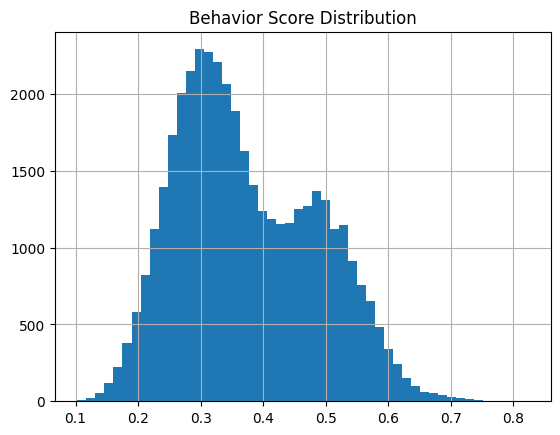

In [42]:
import matplotlib.pyplot as plt

availability_df["behavior_score"].hist(
    bins=50
)

plt.title(
    "Behavior Score Distribution"
)

plt.show()

In [43]:
availability_df.to_csv("candidate_behavior_scores_full.csv", index=False)

Phase 3.3 — Trust & Consistency Forensics

In [44]:
experience_rows = []

for c in candidates:

    claimed_years = (
        c["profile"]["years_of_experience"]
    )

    claimed_months = (
        claimed_years * 12
    )

    actual_months = sum(
        job["duration_months"]
        for job in c["career_history"]
    )

    difference = abs(
        claimed_months - actual_months
    )

    experience_score = max(
        0,
        1 - (
            difference /
            max(claimed_months, 1)
        )
    )

    experience_rows.append({
        "candidate_id": c["candidate_id"],
        "claimed_months": claimed_months,
        "actual_months": actual_months,
        "difference": difference,
        "experience_score": experience_score
    })

In [45]:
experience_df = pd.DataFrame(experience_rows)

experience_df

,candidate_id,claimed_months,actual_months,difference,experience_score
0,CAND_0000001,82.8,82,0.8,0.990338
1,CAND_0000002,150.0,149,1.0,0.993333
2,CAND_0000003,13.2,13,0.2,0.984848
3,CAND_0000004,45.6,44,1.6,0.964912
4,CAND_0000005,132.0,130,2.0,0.984848
...,...,...,...,...,...
99995,CAND_0099996,160.8,159,1.8,0.988806
99996,CAND_0099997,127.2,125,2.2,0.982704
99997,CAND_0099998,87.6,86,1.6,0.981735
99998,CAND_0099999,51.6,50,1.6,0.968992


In [46]:
experience_df.sort_values(
    "experience_score",
    ascending=False
)

,candidate_id,claimed_months,actual_months,difference,experience_score
99975,CAND_0099976,18.0,18,0.0,1.0
99965,CAND_0099966,30.0,30,0.0,1.0
34214,CAND_0034215,60.0,60,0.0,1.0
99938,CAND_0099939,84.0,84,0.0,1.0
82803,CAND_0082804,30.0,30,0.0,1.0
...,...,...,...,...,...
36999,CAND_0037000,32.4,75,42.6,0.0
19479,CAND_0019480,33.6,87,53.4,0.0
10293,CAND_0010294,96.0,220,124.0,0.0
55684,CAND_0055685,16.8,64,47.2,0.0


In [47]:
trust_based_candidates = experience_df[experience_df["experience_score"] <= 0.1]

print(f"Total candidates with experience score <= 0.1: {len(trust_based_candidates)}")
print(f"Sample: {trust_based_candidates}")

Total candidates with experience score <= 0.1: 33
Sample:        candidate_id  claimed_months  actual_months  difference  \
3429   CAND_0003430           164.4             11       153.4   
5290   CAND_0005291           153.6             11       142.6   
7352   CAND_0007353           118.8            251       132.2   
8959   CAND_0008960           123.6            271       147.4   
10293  CAND_0010294            96.0            220       124.0   
18514  CAND_0018515           102.0            211       109.0   
19479  CAND_0019480            33.6             87        53.4   
24751  CAND_0024752           178.8              8       170.8   
25578  CAND_0025579           154.8             12       142.8   
35103  CAND_0035104            66.0            162        96.0   
36298  CAND_0036299           146.4              8       138.4   
36999  CAND_0037000            32.4             75        42.6   
37538  CAND_0037539            58.8            115        56.2   
38430  CAND_003843

In [48]:
experience_df["difference"].describe()

count    100000.000000
mean          1.279914
std           2.680588
min           0.000000
25%           0.600000
50%           1.200000
75%           1.800000
max         185.000000
Name: difference, dtype: float64

In [49]:
experience_df.sort_values(
    "difference",
    ascending=False
).head(100)

,candidate_id,claimed_months,actual_months,difference,experience_score
40074,CAND_0040075,180.0,365,185.0,0.000000
24751,CAND_0024752,178.8,8,170.8,0.044743
96149,CAND_0096150,176.4,10,166.4,0.056689
38430,CAND_0038431,180.0,16,164.0,0.088889
3429,CAND_0003430,164.4,11,153.4,0.066910
...,...,...,...,...,...
88847,CAND_0088848,170.4,166,4.4,0.974178
69337,CAND_0069338,170.4,166,4.4,0.974178
59822,CAND_0059823,164.4,160,4.4,0.973236
15655,CAND_0015656,128.4,124,4.4,0.965732


In [50]:
low_experience_score = experience_df[experience_df["experience_score"] > 0.1]
print(low_experience_score)

       candidate_id  claimed_months  actual_months  difference  \
0      CAND_0000001            82.8             82         0.8   
1      CAND_0000002           150.0            149         1.0   
2      CAND_0000003            13.2             13         0.2   
3      CAND_0000004            45.6             44         1.6   
4      CAND_0000005           132.0            130         2.0   
...             ...             ...            ...         ...   
99995  CAND_0099996           160.8            159         1.8   
99996  CAND_0099997           127.2            125         2.2   
99997  CAND_0099998            87.6             86         1.6   
99998  CAND_0099999            51.6             50         1.6   
99999  CAND_0100000           148.8            147         1.8   

       experience_score  
0              0.990338  
1              0.993333  
2              0.984848  
3              0.964912  
4              0.984848  
...                 ...  
99995          0.988806  

In [51]:
date_rows = []

for c in candidates:

    s = c["redrob_signals"]

    signup = pd.to_datetime(
        s["signup_date"]
    )

    last_active = pd.to_datetime(
        s["last_active_date"]
    )

    anomaly = signup > last_active

    date_rows.append({

        "candidate_id":
        c["candidate_id"],

        "date_anomaly":
        anomaly,

        "date_score":
        0 if anomaly else 1

    })

In [52]:
date_df = pd.DataFrame(
    date_rows
)

In [53]:
date_df["date_anomaly"].sum()

np.int64(7496)

In [54]:
education_rows = []

for c in candidates:
    
    for edu in c["education"]:
        education_end_year = edu["end_year"]
        degree_done = edu["degree"]
    
    
    education_rows.append({
        "candidate_id": c["candidate_id"],
        
        "education_end_year": education_end_year,
        "degree_done" : degree_done
    })

education_df = pd.DataFrame(education_rows)
education_df.head()

,candidate_id,education_end_year,degree_done
0,CAND_0000001,2020,B.E.
1,CAND_0000002,2011,B.Sc
2,CAND_0000003,2021,M.Sc
3,CAND_0000004,2016,Ph.D
4,CAND_0000005,2012,M.Sc


In [55]:

education_df["degree_done"].value_counts()



degree_done
M.S.      12645
M.E.      12621
B.Tech    12544
M.Tech    12524
M.Sc      12520
Ph.D      12508
B.E.      12322
B.Sc      12316
Name: count, dtype: int64

In [56]:
degree_rank = {

    "B.Sc": 1,
    "B.E.": 1,
    "B.Tech": 1,

    "M.Sc": 2,
    "M.S.": 2,
    "M.E.": 2,
    "M.Tech": 2,

    "Ph.D": 3
}

In [57]:
education_anomalies = []

for c in candidates:

    edu = c["education"]

    if len(edu) < 2:
        continue

    ranks = []

    for e in edu:

        degree = e["degree"]

        ranks.append(
            degree_rank.get(
                degree,
                -1
            )
        )

    if ranks != sorted(ranks):

        education_anomalies.append(
            c["candidate_id"]
        )

print(
    len(
        education_anomalies
    )
)

11968


In [58]:
education_anomalies

['CAND_0000026',
 'CAND_0000027',
 'CAND_0000043',
 'CAND_0000044',
 'CAND_0000045',
 'CAND_0000046',
 'CAND_0000050',
 'CAND_0000068',
 'CAND_0000075',
 'CAND_0000081',
 'CAND_0000084',
 'CAND_0000095',
 'CAND_0000123',
 'CAND_0000151',
 'CAND_0000154',
 'CAND_0000155',
 'CAND_0000172',
 'CAND_0000173',
 'CAND_0000176',
 'CAND_0000183',
 'CAND_0000184',
 'CAND_0000192',
 'CAND_0000195',
 'CAND_0000214',
 'CAND_0000218',
 'CAND_0000220',
 'CAND_0000223',
 'CAND_0000225',
 'CAND_0000238',
 'CAND_0000262',
 'CAND_0000273',
 'CAND_0000276',
 'CAND_0000295',
 'CAND_0000299',
 'CAND_0000333',
 'CAND_0000338',
 'CAND_0000356',
 'CAND_0000361',
 'CAND_0000374',
 'CAND_0000378',
 'CAND_0000386',
 'CAND_0000392',
 'CAND_0000397',
 'CAND_0000400',
 'CAND_0000416',
 'CAND_0000417',
 'CAND_0000421',
 'CAND_0000427',
 'CAND_0000431',
 'CAND_0000433',
 'CAND_0000438',
 'CAND_0000450',
 'CAND_0000466',
 'CAND_0000467',
 'CAND_0000478',
 'CAND_0000480',
 'CAND_0000484',
 'CAND_0000492',
 'CAND_0000501

In [59]:
year_anomalies = []

for c in candidates:

    edu = c["education"]

    if len(edu) < 2:
        continue

    years = [
        e["end_year"]
        for e in edu
    ]

    if years != sorted(years):

        year_anomalies.append(
            c["candidate_id"]
        )

print(
    len(
        year_anomalies
    )
)

18594


In [60]:
year_anomalies

['CAND_0000004',
 'CAND_0000012',
 'CAND_0000013',
 'CAND_0000019',
 'CAND_0000032',
 'CAND_0000039',
 'CAND_0000043',
 'CAND_0000044',
 'CAND_0000046',
 'CAND_0000057',
 'CAND_0000060',
 'CAND_0000062',
 'CAND_0000066',
 'CAND_0000074',
 'CAND_0000075',
 'CAND_0000082',
 'CAND_0000089',
 'CAND_0000092',
 'CAND_0000093',
 'CAND_0000095',
 'CAND_0000104',
 'CAND_0000106',
 'CAND_0000109',
 'CAND_0000111',
 'CAND_0000117',
 'CAND_0000124',
 'CAND_0000125',
 'CAND_0000127',
 'CAND_0000128',
 'CAND_0000132',
 'CAND_0000133',
 'CAND_0000139',
 'CAND_0000154',
 'CAND_0000177',
 'CAND_0000178',
 'CAND_0000180',
 'CAND_0000196',
 'CAND_0000208',
 'CAND_0000213',
 'CAND_0000215',
 'CAND_0000223',
 'CAND_0000235',
 'CAND_0000236',
 'CAND_0000238',
 'CAND_0000260',
 'CAND_0000262',
 'CAND_0000265',
 'CAND_0000266',
 'CAND_0000267',
 'CAND_0000274',
 'CAND_0000276',
 'CAND_0000281',
 'CAND_0000282',
 'CAND_0000283',
 'CAND_0000284',
 'CAND_0000285',
 'CAND_0000288',
 'CAND_0000289',
 'CAND_0000295

In [61]:
education_rows_list = []

for c in candidates:
    cid = c["candidate_id"]
    edu = c["education"]
    
    # Check degree anomaly
    if len(edu) < 2:
        degree_anomaly = False
    else:
        ranks = [degree_rank.get(e["degree"], -1) for e in edu]
        degree_anomaly = ranks != sorted(ranks)
    
    # Check year anomaly
    if len(edu) < 2:
        year_anomaly = False
    else:
        years = [e["end_year"] for e in edu]
        year_anomaly = years != sorted(years)
    
    # Calculate scores
    degree_score = 0 if degree_anomaly else 1
    year_score = 0 if year_anomaly else 1
    
    education_score = (0.5 * degree_score + 0.5 * year_score)
    
    education_rows_list.append({
        "candidate_id": cid,
        "degree_anomaly": degree_anomaly,
        "year_anomaly": year_anomaly,
        "degree_score": degree_score,
        "year_score": year_score,
        "education_score": education_score
    })

education_scores_df = pd.DataFrame(education_rows_list)
education_scores_df.head()

,candidate_id,degree_anomaly,year_anomaly,degree_score,year_score,education_score
0,CAND_0000001,False,False,1,1,1.0
1,CAND_0000002,False,False,1,1,1.0
2,CAND_0000003,False,False,1,1,1.0
3,CAND_0000004,False,True,1,0,0.5
4,CAND_0000005,False,False,1,1,1.0


In [62]:
from collections import Counter
import pandas as pd

title_desc_rows = []

for c in candidates:

    total_jobs = 0
    mismatch_jobs = 0

    for job in c["career_history"]:

        total_jobs += 1

        title = str(job["title"]).lower()
        desc = str(job["description"]).lower()

        # Simple consistency check

        title_words = set(title.split())

        matches = sum(
            1
            for word in title_words
            if word in desc
        )

        consistency = (
            matches /
            max(len(title_words), 1)
        )

        if consistency < 0.25:
            mismatch_jobs += 1

    title_description_score = (
        1 -
        (
            mismatch_jobs /
            max(total_jobs,1)
        )
    )

    title_desc_rows.append({

        "candidate_id":
        c["candidate_id"],

        "total_jobs":
        total_jobs,

        "mismatch_jobs":
        mismatch_jobs,

        "title_description_score":
        title_description_score,

        "title_description_anomaly":
        int(
            title_description_score < 0.5
        )

    })

title_desc_df = pd.DataFrame(
    title_desc_rows
)

In [63]:
title_desc_df

,candidate_id,total_jobs,mismatch_jobs,title_description_score,title_description_anomaly
0,CAND_0000001,2,0,1.000000,0
1,CAND_0000002,4,4,0.000000,1
2,CAND_0000003,1,1,0.000000,1
3,CAND_0000004,3,3,0.000000,1
4,CAND_0000005,4,4,0.000000,1
...,...,...,...,...,...
99995,CAND_0099996,5,5,0.000000,1
99996,CAND_0099997,4,3,0.250000,1
99997,CAND_0099998,3,2,0.333333,1
99998,CAND_0099999,2,1,0.500000,0


In [64]:
title_desc_df[
    "title_description_score"
].describe()

count    100000.000000
mean          0.321523
std           0.341393
min           0.000000
25%           0.000000
50%           0.250000
75%           0.500000
max           1.000000
Name: title_description_score, dtype: float64

In [65]:
title_desc_df[
    "title_description_anomaly"
].sum()

np.int64(65904)

In [66]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

c:\Users\kambl\AppData\Local\Programs\Python\Python313\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [67]:
def build_candidate_text(c):

    headline = c["profile"]["headline"]

    summary = c["profile"]["summary"]

    skills = " ".join(
        s["name"]
        for s in c["skills"]
    )

    career = " ".join(
        job["description"]
        for job in c["career_history"]
    )

    return f"""
    Headline:
    {headline}

    Summary:
    {summary}

    Skills:
    {skills}

    Career:
    {career}
    """

In [68]:
sample_candidates = candidates[:100]

In [69]:
texts = [
    build_candidate_text(c)
    for c in sample_candidates
]

In [70]:
embeddings = model.encode(
    texts,
    show_progress_bar=True
)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [71]:
embeddings.shape

(100, 384)

In [72]:
title_emb = model.encode(
    job["title"]
)

desc_emb = model.encode(
    job["description"]
)

In [73]:
title_emb.shape

(384,)

In [74]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(
    [title_emb],
    [desc_emb]
)[0][0]

In [75]:
sim

np.float32(0.25539136)

In [76]:
skills_text = " ".join(
    s["name"]
    for s in c["skills"]
)

In [77]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

title_desc_rows = []

for c in sample_candidates:

    similarities = []

    for job in c["career_history"]:

        title = str(job["title"])
        desc = str(job["description"])

        title_emb = model.encode(
            title,
            convert_to_numpy=True
        )

        desc_emb = model.encode(
            desc,
            convert_to_numpy=True
        )

        sim = cosine_similarity(
            title_emb.reshape(1,-1),
            desc_emb.reshape(1,-1)
        )[0][0]

        similarities.append(sim)

    title_desc_rows.append({

        "candidate_id":
        c["candidate_id"],

        "avg_title_desc_similarity":
        np.mean(similarities),

        "min_title_desc_similarity":
        np.min(similarities),

        "max_title_desc_similarity":
        np.max(similarities)

    })

title_desc_df = pd.DataFrame(
    title_desc_rows
)

In [81]:
title_desc_df

,candidate_id,avg_title_desc_similarity,min_title_desc_similarity,max_title_desc_similarity
0,CAND_0000001,0.293055,0.214464,0.371645
1,CAND_0000002,0.284727,0.221533,0.329931
2,CAND_0000003,0.182714,0.182714,0.182714
3,CAND_0000004,0.227936,0.139916,0.372123
4,CAND_0000005,0.246098,0.148399,0.325621
...,...,...,...,...
95,CAND_0000096,0.276238,0.233043,0.319432
96,CAND_0000097,0.104111,0.078245,0.129977
97,CAND_0000098,0.219866,0.219866,0.219866
98,CAND_0000099,0.389702,0.389702,0.389702


    candidate_id  avg_title_desc_similarity  min_title_desc_similarity  \
0   CAND_0000001                   0.293055                   0.214464   
1   CAND_0000002                   0.284727                   0.221533   
2   CAND_0000003                   0.182714                   0.182714   
3   CAND_0000004                   0.227936                   0.139916   
4   CAND_0000005                   0.246098                   0.148399   
..           ...                        ...                        ...   
95  CAND_0000096                   0.276238                   0.233043   
96  CAND_0000097                   0.104111                   0.078245   
97  CAND_0000098                   0.219866                   0.219866   
98  CAND_0000099                   0.389702                   0.389702   
99  CAND_0000100                   0.165330                   0.089234   

    max_title_desc_similarity  
0                    0.371645  
1                    0.329931  
2              

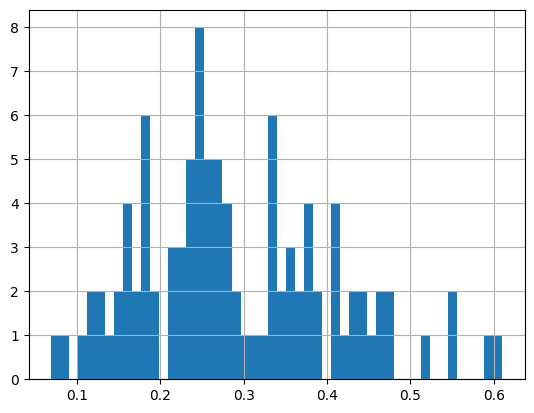

In [78]:
print(title_desc_df)
print(title_desc_df["avg_title_desc_similarity"].describe())
print("medien : ",title_desc_df["avg_title_desc_similarity"].median())
print(title_desc_df["avg_title_desc_similarity"].hist(bins=50))

In [82]:
title_desc_df

,candidate_id,avg_title_desc_similarity,min_title_desc_similarity,max_title_desc_similarity
0,CAND_0000001,0.293055,0.214464,0.371645
1,CAND_0000002,0.284727,0.221533,0.329931
2,CAND_0000003,0.182714,0.182714,0.182714
3,CAND_0000004,0.227936,0.139916,0.372123
4,CAND_0000005,0.246098,0.148399,0.325621
...,...,...,...,...
95,CAND_0000096,0.276238,0.233043,0.319432
96,CAND_0000097,0.104111,0.078245,0.129977
97,CAND_0000098,0.219866,0.219866,0.219866
98,CAND_0000099,0.389702,0.389702,0.389702


In [83]:
title_desc_df.sort_values(
    "avg_title_desc_similarity",
    ascending=False
).head(10)

,candidate_id,avg_title_desc_similarity,min_title_desc_similarity,max_title_desc_similarity
66,CAND_0000067,0.610005,0.547828,0.672181
89,CAND_0000090,0.597355,0.597355,0.597355
9,CAND_0000010,0.548340,0.548340,0.548340
55,CAND_0000056,0.547828,0.547828,0.547828
13,CAND_0000014,0.513630,0.363499,0.695701
61,CAND_0000062,0.479503,0.479503,0.479503
24,CAND_0000025,0.478192,0.369438,0.695701
63,CAND_0000064,0.463587,0.325621,0.601553
34,CAND_0000035,0.461702,0.361910,0.561494
94,CAND_0000095,0.456186,0.355267,0.557104


In [84]:
top_3 = title_desc_df.sort_values(
    "avg_title_desc_similarity",
    ascending=False
).head(10)

for idx, row in top_3.iterrows():
    cand_id = row["candidate_id"]
    cand = next(c for c in candidates if c["candidate_id"] == cand_id)
    
    print(f"\n{'='*60}")
    print(f"Candidate: {cand_id}")
    print(f"{'='*60}")
    
    for job in cand["career_history"]:
        print(f"\nTitle: {job['title']}")
        print(f"Description: {job['description']}")


Candidate: CAND_0000067

Title: Frontend Engineer
Description: Full-stack web application development at a SaaS company. Built React-based admin interfaces and the Node.js REST API backing them. Worked across the stack: frontend components, REST endpoint design, PostgreSQL schema, deployment via Docker/Kubernetes. Comfortable in most parts of a typical web stack though my comfort zone is the backend and database side. Recent learning has been on the testing and CI/CD discipline.

Title: Mobile Developer
Description: Android mobile development using Java and (more recently) Kotlin at a consumer-app company. Built and maintained multiple production features including the main shopping flow, push notification system, and the offline-first sync layer. Comfortable with the Android framework, Jetpack components, and the typical patterns (MVVM, Hilt, Coroutines). My career has been entirely on mobile so far; interested in expanding into broader backend or platform engineering.

Candidate: CA

In [85]:
title_desc_df.sort_values(
    "avg_title_desc_similarity",
    ascending=True
).head(10)

,candidate_id,avg_title_desc_similarity,min_title_desc_similarity,max_title_desc_similarity
51,CAND_0000052,0.069191,0.069191,0.069191
27,CAND_0000028,0.089234,0.089234,0.089234
96,CAND_0000097,0.104111,0.078245,0.129977
6,CAND_0000007,0.121716,0.109191,0.134241
65,CAND_0000066,0.121808,0.121808,0.121808
19,CAND_0000020,0.124599,0.078245,0.167724
25,CAND_0000026,0.131682,0.085650,0.162603
35,CAND_0000036,0.140550,0.098363,0.229029
38,CAND_0000039,0.151958,0.139916,0.164000
52,CAND_0000053,0.155397,0.146794,0.164000


In [86]:
top__last_3 = title_desc_df.sort_values(
    "avg_title_desc_similarity",
    ascending=True
).head(10)

for idx, row in top__last_3.iterrows():
    cand_id = row["candidate_id"]
    cand = next(c for c in candidates if c["candidate_id"] == cand_id)
    
    print(f"\n{'='*60}")
    print(f"Candidate: {cand_id}")
    print(f"{'='*60}")
    
    for job in cand["career_history"]:
        print(f"\nTitle: {job['title']}")
        print(f"Description: {job['description']}")


Candidate: CAND_0000052

Title: Mechanical Engineer
Description: Enterprise sales of cloud software solutions into the mid-market segment. Carried a $1.8M ARR quota and consistently delivered against it across the last three years. Owned the full sales cycle: prospecting, discovery, technical evaluation (with SE support), commercial negotiation, and close. Strong on consultative selling for technical buyers; comfortable engaging with both engineering and finance stakeholders.

Candidate: CAND_0000028

Title: Operations Manager
Description: Brand design and creative direction at a consumer-products company. Owned brand identity (logo, visual system, typography), packaging design, and digital creative across web and social. Led the recent rebrand and managed a small external agency for production work. Comfortable across the Adobe suite, Figma, and the production side of brand and packaging design.

Candidate: CAND_0000097

Title: Mechanical Engineer
Description: Marketing leadership ro

In [87]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

skill_rows = []

for c in sample_candidates:

    skills_text = " ".join(
        skill["name"]
        for skill in c["skills"]
    )

    career_text = " ".join(
        job["description"]
        for job in c["career_history"]
    )

    skill_emb = model.encode(
        skills_text,
        convert_to_numpy=True
    )

    career_emb = model.encode(
        career_text,
        convert_to_numpy=True
    )

    similarity = cosine_similarity(
        skill_emb.reshape(1,-1),
        career_emb.reshape(1,-1)
    )[0][0]

    skill_rows.append({
        "candidate_id":
        c["candidate_id"],

        "skill_desc_similarity":
        similarity
    })

skill_desc_df = pd.DataFrame(
    skill_rows
)

In [88]:
skill_desc_df[
    "skill_desc_similarity"
].describe()

count    100.000000
mean       0.159963
std        0.086588
min        0.014485
25%        0.092306
50%        0.149390
75%        0.218772
max        0.373641
Name: skill_desc_similarity, dtype: float64

In [89]:
skill_desc_df.sort_values(
    "skill_desc_similarity"
).head(10)

,candidate_id,skill_desc_similarity
5,CAND_0000006,0.014485
27,CAND_0000028,0.024011
33,CAND_0000034,0.033615
22,CAND_0000023,0.036191
14,CAND_0000015,0.039232
12,CAND_0000013,0.039631
8,CAND_0000009,0.044054
65,CAND_0000066,0.045119
68,CAND_0000069,0.049154
64,CAND_0000065,0.049887


In [90]:
top_5_candidates = skill_desc_df.sort_values(
    "skill_desc_similarity",
    ascending=False
).head(5)

for idx, row in top_5_candidates.iterrows():
    cand_id = row["candidate_id"]
    cand = next(c for c in candidates if c["candidate_id"] == cand_id)
    
    print(f"\n{'='*60}")
    print(f"Candidate: {cand_id}")
    print(f"Skill-Description Similarity: {row['skill_desc_similarity']:.4f}")
    print(f"{'='*60}")
    
    print("\nSkills:")
    for skill in cand["skills"]:
        print(f"  - {skill['name']} ({skill['proficiency']})")
    
    print("\nCareer History:")
    for job in cand["career_history"]:
        print(f"\n  Title: {job['title']}")
        print(f"  Description: {job['description']}")


Candidate: CAND_0000099
Skill-Description Similarity: 0.3736

Skills:
  - Figma (intermediate)
  - Salesforce CRM (beginner)
  - Haystack (advanced)
  - Weights & Biases (advanced)
  - Airflow (intermediate)
  - Hugging Face Transformers (advanced)
  - Hadoop (beginner)
  - Six Sigma (beginner)
  - MongoDB (intermediate)
  - Content Writing (intermediate)
  - Spring Boot (intermediate)
  - Marketing (beginner)
  - YOLO (advanced)
  - Docker (beginner)
  - Go (beginner)
  - Azure (beginner)

Career History:

  Title: Full Stack Developer
  Description: Cloud infrastructure and DevOps work at an enterprise SaaS company. Owned the AWS account architecture (VPC, IAM, networking), the Terraform modules for our service deployments, and the Kubernetes cluster operations. Designed the CI/CD pipelines (GitLab CI + ArgoCD) and the monitoring stack (Prometheus, Grafana, Loki). Strong on the infra and ops side; haven't done much application development.

  Title: Full Stack Developer
  Descriptio

In [97]:
skill_anomaly_rows = []

for idx, row in skill_desc_df.iterrows():
    if row["skill_desc_similarity"] < 0.1:
        skill_anomaly_rows.append({
            "candidate_id": row["candidate_id"],
            "skill_desc_similarity": row["skill_desc_similarity"],
            "skill_anomaly": True
        })


skill_anomaly_df = pd.DataFrame(skill_anomaly_rows)
skill_anomaly_df.head()

,candidate_id,skill_desc_similarity,skill_anomaly
0,CAND_0000005,0.073007,True
1,CAND_0000006,0.014485,True
2,CAND_0000009,0.044054,True
3,CAND_0000013,0.039631,True
4,CAND_0000015,0.039232,True


In [107]:
# Load the existing CSV file
behavior_df = pd.read_csv("candidate_behavior_scores_full.csv")

# Merge with title_description_anomaly from title_desc_df
# behavior_df = behavior_df.merge(
#     title_desc_df[["candidate_id", "title_description_anomaly"]],
#     on="candidate_id",
#     how="left"
# )

# # Merge with date_anomaly from date_df
# behavior_df = behavior_df.merge(
#     date_df[["candidate_id", "date_anomaly"]],
#     on="candidate_id",
#     how="left"
# )

# # Merge with education_score from education_scores_df
# behavior_df = behavior_df.merge(
#     education_scores_df[["candidate_id", "education_score"]],
#     on="candidate_id",
#     how="left"
# )

behavior_df = behavior_df.merge(
    skill_desc_df[["candidate_id", "skill_desc_similarity"]],
    on="candidate_id",
    how="left"
)

behavior_df = behavior_df.merge(
    skill_anomaly_df[["candidate_id", "skill_anomaly"]],
    on="candidate_id",
    how="left"
)


# Save the updated dataframe back to CSV
behavior_df.to_csv("candidate_behavior_scores_full.csv", index=False)

print(behavior_df.head())
print(behavior_df.shape)

C:\Users\kambl\AppData\Local\Temp\ipykernel_28240\1224791896.py:2: DtypeWarning: Columns (0: skill_anomaly) have mixed types. Specify dtype option on import or set low_memory=False.
  behavior_df = pd.read_csv("candidate_behavior_scores_full.csv")


   candidate_id  profile_completeness  open_to_work  response_rate  \
0  CAND_0000001                  86.9          True           0.34   
1  CAND_0000002                  78.7          True           0.29   
2  CAND_0000003                  31.9         False           0.46   
3  CAND_0000004                  28.5         False           0.26   
4  CAND_0000005                  84.6          True           0.37   

   response_time  views  applications  connections  search_appearance  saved  \
0          177.8     23             2          356                249      4   
1          171.6      7             1          179                107     10   
2          119.4      1             9           19                 28      4   
3          104.1      3             9          485                  5      8   
4          116.7     12             2          300                 67      1   

   ...  date_anomaly_y  education_score_x  skill_desc_similarity_x  \
0  ...           False      